HW2 - ENME485 - Merrick Summers - Shaft Health Assessment

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SAMPLING_RATE = 2560  # Hz
SHAFT_FREQUENCY = 20  # Hz (1X)
HARMONIC_HALF_WIDTH = 0.5  # Hz
TOP_N_FEATURES = 3

Load the data.

In [2]:
def load_signal(path):
    return np.loadtxt(path, skiprows=5)

healthy_files = sorted(Path('training-data/healthy').glob('*'))
faulty_files = sorted(Path('training-data/faulty').glob('*'))
test_files = sorted(Path('testing-data').glob('*'))
healthy_signals = [load_signal(path) for path in healthy_files]
faulty_signals = [load_signal(path) for path in faulty_files]
test_signals = [load_signal(path) for path in test_files]

Visualize example observations from healthy/faulty training sets.

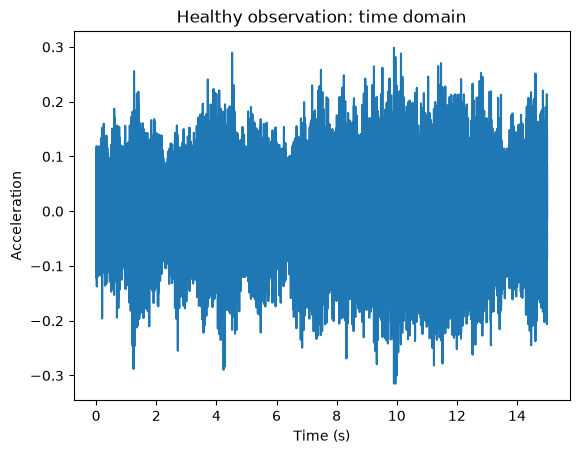

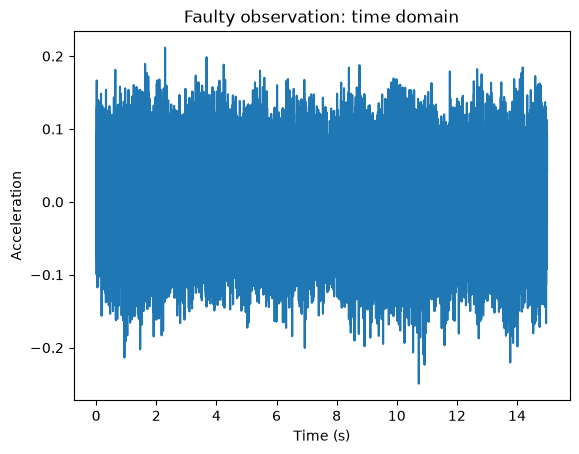

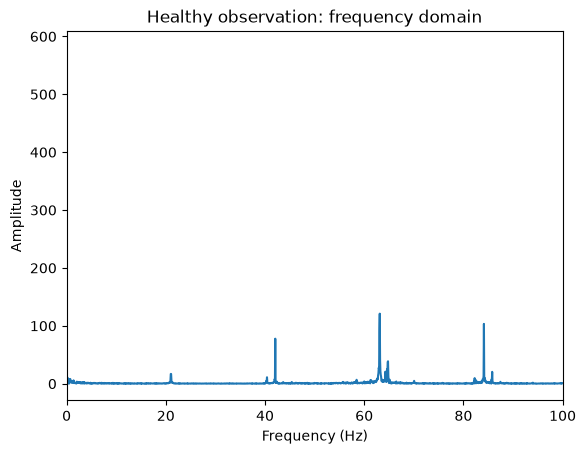

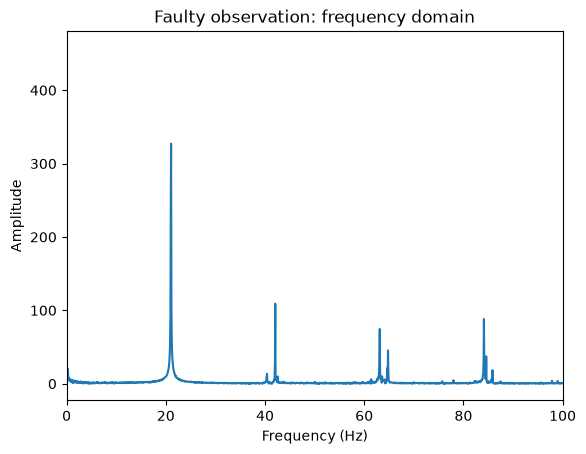

In [3]:
def one_sided_spectrum(signal, sampling_rate=SAMPLING_RATE):
    sample_count = len(signal)
    frequencies = rfftfreq(sample_count, d=1 / sampling_rate)
    amplitudes = np.abs(rfft(signal))
    return frequencies, amplitudes

healthy_example = healthy_signals[0]
faulty_example = faulty_signals[0]
time = np.arange(len(healthy_example)) / SAMPLING_RATE
healthy_frequency, healthy_amplitude = one_sided_spectrum(healthy_example)
faulty_frequency, faulty_amplitude = one_sided_spectrum(faulty_example)

plt.figure()
plt.plot(time, healthy_example)
plt.title('Healthy observation: time domain')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.show()

plt.figure()
plt.plot(time, faulty_example)
plt.title('Faulty observation: time domain')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.show()

plt.figure()
plt.plot(healthy_frequency, healthy_amplitude)
plt.title('Healthy observation: frequency domain')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 100)
plt.show()

plt.figure()
plt.plot(faulty_frequency, faulty_amplitude)
plt.title('Faulty observation: frequency domain')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 100)
plt.show()

Extract candidate features.

In [4]:
def band_peak(frequencies, amplitudes, center, half_width=HARMONIC_HALF_WIDTH):
    in_band = (frequencies >= center - half_width) & (frequencies <= center + half_width)
    return amplitudes[in_band].max()

def extract_features(signal):
    frequencies, amplitudes = one_sided_spectrum(signal)
    rms = np.sqrt(np.mean(signal**2))
    amplitude_1x = band_peak(frequencies, amplitudes, SHAFT_FREQUENCY)
    amplitude_2x = band_peak(frequencies, amplitudes, 2 * SHAFT_FREQUENCY)
    amplitude_3x = band_peak(frequencies, amplitudes, 3 * SHAFT_FREQUENCY)
    return {
        'Mean': np.mean(signal),
        'Standard deviation': np.std(signal, ddof=1),
        'RMS': rms,
        '1X amplitude': amplitude_1x,
        '2X amplitude': amplitude_2x,
        '3X amplitude': amplitude_3x,
        '1X-to-RMS ratio': amplitude_1x / rms,
    }

healthy_features = pd.DataFrame([extract_features(signal) for signal in healthy_signals])
faulty_features = pd.DataFrame([extract_features(signal) for signal in faulty_signals])
test_features = pd.DataFrame([extract_features(signal) for signal in test_signals])
training_features = pd.concat([healthy_features, faulty_features], ignore_index=True)
training_labels = np.concatenate([
    np.zeros(len(healthy_features), dtype=int),
    np.ones(len(faulty_features), dtype=int),
])
training_features.head()

,Mean,Standard deviation,RMS,1X amplitude,2X amplitude,3X amplitude,1X-to-RMS ratio
0,0.000142,0.066410,0.066409,1.193185,11.113439,3.941002,17.967151
1,0.000183,0.092480,0.092479,1.318693,9.643294,3.960779,14.259423
2,0.000012,0.070199,0.070198,1.226031,13.025343,2.603423,17.465409
3,0.000321,0.076685,0.076684,1.439356,12.695427,2.670085,18.769857
4,0.000593,0.073980,0.073982,1.804855,13.984368,3.510976,24.395996


Select critical features w/ Fisher's criterion.

In [5]:
def fisher_scores(healthy, faulty):
    numerator = (faulty.mean() - healthy.mean()) ** 2
    denominator = faulty.var() + healthy.var()
    return (numerator / (denominator)).sort_values(ascending=False)

feature_scores = fisher_scores(healthy_features, faulty_features)
selected_features = feature_scores.head(TOP_N_FEATURES).index.tolist()

fisher_table = feature_scores.rename('Fisher score').to_frame()
fisher_table['Selected'] = fisher_table.index.isin(selected_features)
display(fisher_table)
print('Selected features:', selected_features)

,Fisher score,Selected
1X amplitude,87.634845,True
1X-to-RMS ratio,42.896531,True
2X amplitude,6.147232,True
3X amplitude,1.195740,False
RMS,0.595982,False
Standard deviation,0.595804,False
Mean,0.192327,False


Selected features: ['1X amplitude', '1X-to-RMS ratio', '2X amplitude']


Train the logistic regression model.

In [6]:
scaler = StandardScaler()
scaled_training_features = scaler.fit_transform(training_features[selected_features])

model = LogisticRegression()
model.fit(scaled_training_features, training_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

Run logistic regression model on test data.

In [7]:
scaled_test_features = scaler.transform(test_features[selected_features])
faulty_probability = model.predict_proba(scaled_test_features)[:, 1]
confidence_value = 1 - faulty_probability
results = pd.DataFrame({
    'Observation': np.arange(1, len(test_files) + 1),
    'Filename': [path.name for path in test_files],
    'CV': confidence_value,
})
results.to_csv('test_assessment_results.csv', index=False)
display(results)

,Observation,Filename,CV
0,1,Data Mar-26-14 Time 1533-21.txt,0.981539
1,2,Data Mar-26-14 Time 1534-22.txt,0.987302
2,3,Data Mar-26-14 Time 1540-23.txt,0.973013
3,4,Data Mar-26-14 Time 1540-24.txt,0.986446
4,5,Data Mar-26-14 Time 1540-25.txt,0.984874
5,6,Data Mar-26-14 Time 1543-26.txt,0.975802
6,7,Data Mar-26-14 Time 1543-27.txt,0.981741
7,8,Data Mar-26-14 Time 1543-28.txt,0.984713
8,9,Data Mar-26-14 Time 1544-29.txt,0.978189
9,10,Data Mar-26-14 Time 1544-30.txt,0.964502


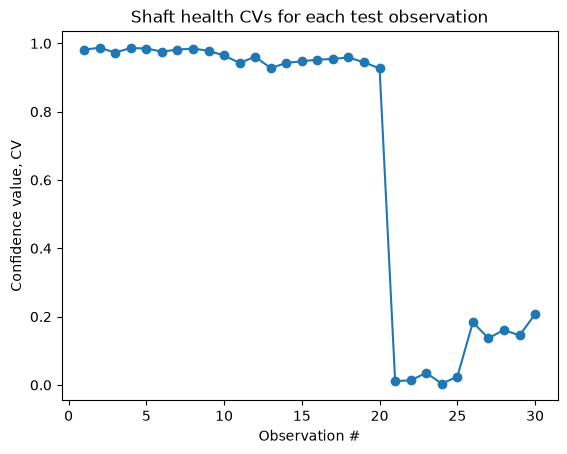

In [8]:
plt.figure()
plt.plot(results['Observation'], results['CV'], marker='o')
plt.title('Shaft health CVs for each test observation')
plt.xlabel('Observation #')
plt.ylabel('Confidence value, CV')
plt.show()